In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
job_array=False;index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [2]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [3]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    W = f['W'][:]
    QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]
    
#Making Time Matrix
Nt=len(data['time'])
T = np.broadcast_to(np.arange(Nt)[:, None], A_c.shape)  # shape: (Nt, p)

In [4]:
#TRACKED TRAJECTORY ENTRAINMENT/DETRAINMENT
################################################################

In [5]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=(data['xf'][-1].item()-data['xf'][0].item())*1000 #x length (m)
Ly=(data['yf'][-1].item()-data['yf'][0].item())*1000 #y length (m)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out

# rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len(data['zh'])):
        dz=(zf(k+1)-zf(k))
        for j in range(len(data['yh'])):
            for i in range(len(data['xh'])):
                rho_out=rho(i,j,k,t)
                m+=rho_out*dz
                
    #triple sum
    out=m*dx*dy/Np
    return out

In [6]:
#Calculate Mass Constant
calculate=False
if calculate==True:
    Nt=len(data['time'])
    m_arr=np.zeros((Nt))
    for t in np.arange(Nt):
        print(t)
        m_arr[t]=m(t)
    np.save('Mass_Array.npy', m_arr)
else:
    dir3=dir+f'Project_Algorithms/Entrainment/'
    m_arr = np.load('Mass_Array.npy')

In [ ]:
# # Reading Back Data Later
# ##############
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# # in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
# with h5py.File(in_file, 'r') as f:
#     # Load the dataset by its name
#     A_g = f['A_g'][:]
#     A_c = f['A_c'][:]

#     W = f['W'][:]
#     QCQI = f['QCQI'][:]
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

# # #Making Time Matrix
# # rows, cols = A.shape[0], A.shape[1]
# # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [ ]:
# #READING BACK IN
# mins_thresh=5
# # mins_thresh=10
# dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
# with h5py.File(dir3, 'r') as h5file:
#     A_g_Processed = h5file['A_g_Processed'][:]
#     A_c_Processed = h5file['A_c_Processed'][:]

In [7]:
#READING BACK IN
PROCESSING=False
PROCESSING=True

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/3D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

e_copy = profile_array_e_c.copy()#TESTING

def apply_constant(profile_array,apply):
    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(dx*dy*dt)
        for t in np.arange(Nt):
            profile_array[t]*=m_arr[t]
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

#APPLY CONSTANTS TO ENTRAINMENT VALUE
##################################################
profile_array_e_g=apply_constant(profile_array_e_g,apply=True)
profile_array_e_c=apply_constant(profile_array_e_c,apply=True)
profile_array_d_g=-apply_constant(profile_array_d_g,apply=True)
profile_array_d_c=-apply_constant(profile_array_d_c,apply=True)
##################################################

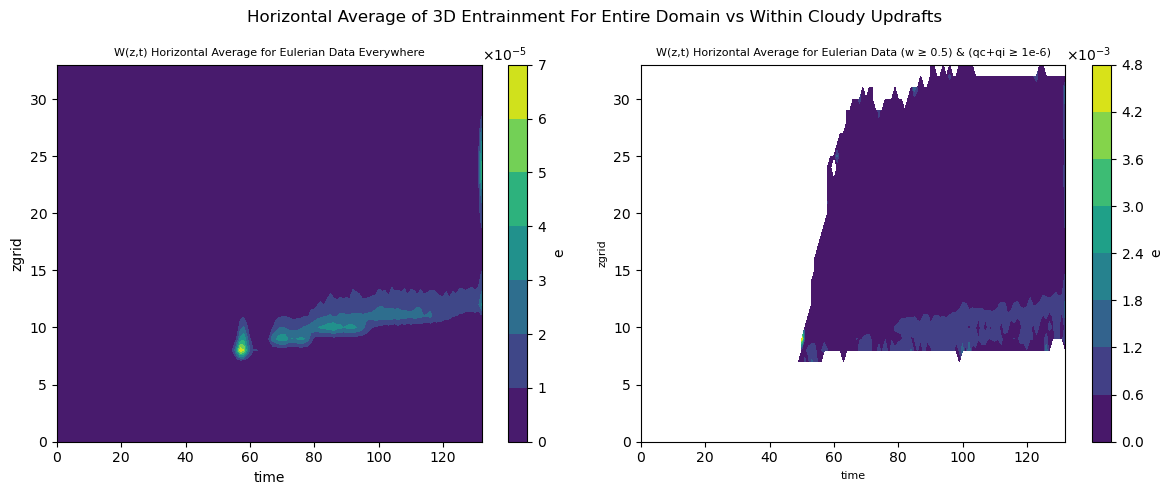

In [9]:
#TESTING W (T,Z) PLOT


masked_profile2 = profile_array_e_c.copy()
e_tz = np.nanmean(masked_profile2, axis=(2, 3))
print('done')

# New Subplots for Contour Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First contour plot
cf1 = axes[0].contourf(e_tz.T)
cbar1 = plt.colorbar(cf1, ax=axes[0],label='e')  
apply_scientific_notation_colorbar([cbar1])
axes[0].set_ylabel('zgrid')
axes[0].set_xlabel('time')
axes[0].set_title('W(z,t) Horizontal Average for Eulerian Data Everywhere',fontsize=8)


mask1 = (data['winterp'] >= 0.5) & ((data['qc'] + data['qi']) >= 1e-6)
# masked_profile1 = np.ma.masked_where(~mask1, profile_array_e_c)
masked_profile1 = np.where(~mask1, np.nan, profile_array_e_c)
e_tz_A = np.nanmean(masked_profile1, axis=(2, 3))
print('done')

# Second contour plot
cf2 = axes[1].contourf(e_tz_A.T, cmap='viridis')  # Adjust the colormap as needed
cbar2 = plt.colorbar(cf2, ax=axes[1], label='e')
apply_scientific_notation_colorbar([cbar2])
axes[1].set_ylabel('zgrid', fontsize=8)
axes[1].set_xlabel('time', fontsize=8)
axes[1].set_title('W(z,t) Horizontal Average for Eulerian Data (w ≥ 0.5) & (qc+qi ≥ 1e-6)',fontsize=8)


plt.suptitle('Horizontal Average of 3D Entrainment For Entire Domain vs Within Cloudy Updrafts')
plt.tight_layout()

In [6]:
#DOMAIN SUBSETTING
def DOMAIN_SUBSET(out_arr):
    print(f'length before: {len(out_arr)}')

    ocean_percent=2/8
    left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
    
    where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
    where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
    end_xh=len(data['xh'])-1-50
    end_xf=len(data['xf'])-1-50
    
    print(f'x in {0}:{where_coast_xh-1} FOR SEA')
    print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
    # t_end=78 
    # if res=='250m':t_end=410
    # print(f't in {0}:{t_end} (6.5 hours)')
    t_start=36 
    t_end=len(data['time'])
    print(f't in {t_start}:end (8 hours)')

    #SUBSETTING CODE
    xs=X[list(out_arr[:,1]),list(out_arr[:,0])]
    
    out_arr=out_arr[np.where((xs>=where_coast_xh)&(xs<=end_xh))]
    out_arr=out_arr[np.where(out_arr[:,1]<=t_end)]

    print(f'length after: {len(out_arr)}')
    return out_arr

In [7]:
# out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
# save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2]] = out[:, [0,1,2]].astype(int) #***
save=xr.open_dataset(dir+f'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_{res}_{Np_str}.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2]] = save[:, [0,1,2]].astype(int) #***

out_arr=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_arr[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_arr[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_arr[:,0] == elem)[0] 
    extras=idx[np.where(out_arr[idx,5]!=np.min(out_arr[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_arr), dtype=bool); mask[lst] = False
out_arr=out_arr[mask]; 
###############################################################################

out_arr=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_arr[:15])
save_arr=save[~np.all(save == 0, axis=1)];save_arr=save_arr[np.where(np.unique(save_arr[1:-1,0]))];print('list of first 10 ignored parcels');print(save_arr[:5])
placeholder=out_arr.copy(); run=True
############################################################
print(f'there are a total of {len(out_arr)} CL parcels and {len(save_arr)} nonCL parcels')

############################################################
#SUBSETTING
subset=True
if subset==True:
    out_arr=DOMAIN_SUBSET(out_arr)
    save_arr=DOMAIN_SUBSET(save_arr)
############################################################

ALL_out_arr=out_arr.copy(); ALL_save_arr=save_arr.copy()

list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
list of first 10 ignored parcels
[[72 65 72]
 [149 52 57]
 [160 54 59]
 [232 53 58]
 [246 55 59]]
there are a total of 14941 CL parcels and 14725 nonCL parcels
length before: 14941
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 14894
length before: 14725
x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)
length after: 11170


In [8]:
#SHALLOW
parcel_z=parcel['z'].data

def ddt(f,dt=1):
    ddx = (
            f[1:  ]
            -
            f[0:-1]
        ) / (
        2 * dt
    )
    return ddx

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        elif np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_arr=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_arr=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(SHALLOW_out_arr)} CL parcels and {len(SHALLOW_save_arr)} nonCL parcels')

0/14894
5000/14894
10000/14894
0/11170
5000/11170
10000/11170
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 10240 CL parcels and 8498 nonCL parcels


In [9]:
#DEEP
parcel_z=parcel['z'].data

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_arr=ALL_out_arr.copy()
    elif type=='nonCL':
        out_arr=ALL_save_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################

convectivelevel=6 #4km
DEEP_out_arr=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_arr=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_arr[:15])
print(f'there are a total of {len(DEEP_out_arr)} CL parcels and {len(DEEP_save_arr)} nonCL parcels')

0/14894
5000/14894
10000/14894
0/11170
5000/11170
10000/11170
list of first 10 SBZ parcels
[[18 76 80]
 [74 65 70]
 [126 67 73]
 [128 80 84]
 [244 72 76]
 [398 54 58]
 [444 54 60]
 [635 55 59]
 [741 76 80]
 [743 82 85]
 [812 62 66]
 [880 80 87]
 [954 72 76]
 [1007 107 111]
 [1022 68 71]]
there are a total of 1513 CL parcels and 1130 nonCL parcels


In [10]:
#FINDING MEAN CLOUD BASE #*****************************
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'

if type=='all':
    out_arr=ALL_out_arr.copy()
elif type=='deep':
    out_arr=DEEP_out_arr.copy()
elif type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14894
3000/14894
6000/14894
9000/14894
12000/14894
1.2463868


In [11]:
#FIND WHERE PARCEL LEAVES UPDRAFT (FOR ALL AND DEEP PARCELS)
def find_after_time(out_arr):
    wthresh=0.5;qcqithresh=1e-6
    
    after_array=np.zeros(len(out_arr),dtype=int)
    for count,out_row in enumerate(out_arr): 
        
        p=out_row[0]
        t2=out_row[2]
        
        wthresh=0.5;qcqithresh=1e-6
        after=np.where((W[t2:,p]<wthresh)|(QCQI[t2:,p]<qcqithresh))
        if len(after[0])!=0:
            after_array[count]=after[0][0]
    return after_array

ALL_out_after_array=find_after_time(ALL_out_arr)
SHALLOW_out_after_array=np.zeros(len(SHALLOW_out_arr),dtype=int)
DEEP_out_after_array=find_after_time(DEEP_out_arr)

ALL_save_after_array=find_after_time(ALL_save_arr)
SHALLOW_save_after_array=np.zeros(len(SHALLOW_save_arr),dtype=int)
DEEP_save_after_array=find_after_time(DEEP_save_arr)

# # Create a figure and specify gridspec layout
# fig = plt.figure(figsize=(8, 4))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])  # 1 row, 2 columns
# ax0 = plt.subplot(gs[0])
# ax0.hist(ALL_after_array, bins=25)
# ax0.set_xlabel('time')
# ax0.set_ylabel('count')
# ax0.set_title('ALL_after')
# ax1 = plt.subplot(gs[1])
# ax1.hist(DEEP_after_array, bins=25)
# ax1.set_xlabel('time')
# ax1.set_ylabel('count')
# ax1.set_title('DEEP_after')
# plt.tight_layout()

# # Multiply x-ticks by 5
# xticks = ax0.get_xticks()  # Get current x-tick positions
# ax0.set_xticks(xticks)  # Set the same ticks
# ax0.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# # Multiply x-ticks by 5
# xticks = ax1.get_xticks()  # Get current x-tick positions
# ax1.set_xticks(xticks)  # Set the same ticks
# ax1.set_xticklabels([int(x * 5) for x in xticks])  # Multiply tick labels by 5

# ax0.set_xlim(left=0);ax1.set_xlim(left=0)

In [24]:
##########################################################################################
#(ALL, SHALLOW, DEEP) CL vs NonCL Tracked Entrainment Profiles

In [12]:
#MAKING ENTRAINMENT PROFILE ARRAY FUNCTION

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
    
def CLTrackedEDProfile(type,type2):

    if type2=='general':
        profile_array_e=profile_array_e_g #PRECALCULATED
        profile_array_d=profile_array_d_g #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d
    elif type2=='cloudy':
        profile_array_e=profile_array_e_c #PRECALCULATED
        profile_array_d=profile_array_d_c #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d

    if type=='all':
        out_arr=ALL_out_arr
        after_array=ALL_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_out_arr
        after_array=SHALLOW_out_after_array
    elif type=='deep':
        out_arr=DEEP_out_arr
        after_array=DEEP_out_after_array
    
    
    zhs=data['zh'].values
    e_profile=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    d_profile=e_profile.copy()
    net_profile=e_profile.copy()
    e_profile[:,2]=zhs;d_profile[:,2]=zhs;net_profile[:,2]=zhs


    global e_lst
    e_lst=[]#TESTING
    for count, row in enumerate(range(out_arr.shape[0])):
    # for count,row in enumerate(np.arange(100)): #TESTING
        if np.mod(count,1000)==True: print(f'{count*100/len(out_arr):.2f}%')
        after=after_array[row]
        p=out_arr[row,0]
        
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            
            e=profile_array_e[t,z,y,x] 
            d=profile_array_d[t,z,y,x] 
            e_lst.append(e)#TESTING
                
            e_profile[z,0]+=e;e_profile[z,1]+=1
            d_profile[z,0]+=d;d_profile[z,1]+=1
            net_profile[z,0]+=e-d;net_profile[z,1]+=1
    
    print('done\n')
    return e_profile,d_profile,net_profile

In [8]:
# #TESTING HISTOGRAMS
# out=profile_array_e_c.copy();
# out[out==0]=np.nan
# plt.hist(out.flatten())


# #TESTING HISTOGRAMS
# type2='cloudy'
# [CL_ALL_e,CL_ALL_d,CL_ALL_net] = CLTrackedEDProfile(type='all',type2=type2)

# e_lst=np.array(e_lst)
# e_lst[e_lst==0]=np.nan
# plt.hist(e_lst)
# plt.title('Histogram of Tracked-Parcels Binned Entrainment Values')

In [28]:
type2='general'
type2='cloudy'
[CL_ALL_e,CL_ALL_d,CL_ALL_net] = CLTrackedEDProfile(type='all',type2=type2)
[CL_SHALLOW_e,CL_SHALLOW_d,CL_SHALLOW_net] = CLTrackedEDProfile(type='shallow',type2=type2)
[CL_DEEP_e,CL_DEEP_d,CL_DEEP_net] = CLTrackedEDProfile(type='deep',type2=type2)

#SAVING
import h5py
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'CL_tracked_profiles.h5'
with h5py.File(filePath, 'w') as h5f:
    h5f.create_dataset('CL_ALL_e', data=CL_ALL_e)
    h5f.create_dataset('CL_ALL_d', data=CL_ALL_d)
    h5f.create_dataset('CL_ALL_net', data=CL_ALL_net)
    h5f.create_dataset('CL_SHALLOW_e', data=CL_SHALLOW_e)
    h5f.create_dataset('CL_SHALLOW_d', data=CL_SHALLOW_d)
    h5f.create_dataset('CL_SHALLOW_net', data=CL_SHALLOW_net)
    h5f.create_dataset('CL_DEEP_e', data=CL_DEEP_e)
    h5f.create_dataset('CL_DEEP_d', data=CL_DEEP_d)
    h5f.create_dataset('CL_DEEP_net', data=CL_DEEP_net)

0.01%
6.72%
13.43%
20.15%
26.86%
33.58%
40.29%
47.01%
53.72%
60.43%
67.15%
73.86%
80.58%
87.29%
94.00%
done

0.01%
9.78%
19.54%
29.31%
39.07%
48.84%
58.60%
68.37%
78.13%
87.90%
97.67%
done

0.07%
66.16%
done



In [67]:
#MAKING ENTRAINMENT PROFILE ARRAY FUNCTION

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
    
def nonCLTrackedEDProfile(type,type2):

    if type2=='general':
        profile_array_e=profile_array_e_g #PRECALCULATED
        profile_array_d=profile_array_d_g #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d
    elif type2=='cloudy':
        profile_array_e=profile_array_e_c #PRECALCULATED
        profile_array_d=profile_array_d_c #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d

    if type=='all':
        out_arr=ALL_save_arr
        after_array=ALL_save_after_array
    elif type=='shallow':
        out_arr=SHALLOW_save_arr
        after_array=SHALLOW_save_after_array
    elif type=='deep':
        out_arr=DEEP_save_arr
        after_array=DEEP_save_after_array
    
    
    zhs=data['zh'].values
    e_profile=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    d_profile=e_profile.copy()
    net_profile=e_profile.copy()
    e_profile[:,2]=zhs;d_profile[:,2]=zhs;net_profile[:,2]=zhs
    
    for count, row in enumerate(range(out_arr.shape[0])):
    # for count,row in enumerate(np.arange(100)): #TESTING
        if np.mod(count,1000)==True: print(f'{count*100/len(out_arr):.2f}%')
        after=after_array[row]
        p=out_arr[row,0]
        
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):

            e=profile_array_e[t,z,y,x] 
            d=profile_array_d[t,z,y,x] 
                
            e_profile[z,0]+=e;e_profile[z,1]+=1
            d_profile[z,0]+=d;d_profile[z,1]+=1
            net_profile[z,0]+=e-d;net_profile[z,1]+=1
    
    print('done\n')
    return e_profile,d_profile,net_profile

In [68]:
type2='general'
type2='cloudy'

[nonCL_ALL_e,nonCL_ALL_d,nonCL_ALL_net] = nonCLTrackedEDProfile(type='all',type2=type2)
[nonCL_SHALLOW_e,nonCL_SHALLOW_d,nonCL_SHALLOW_net] = nonCLTrackedEDProfile(type='shallow',type2=type2)
[nonCL_DEEP_e,nonCL_DEEP_d,nonCL_DEEP_net] = nonCLTrackedEDProfile(type='deep',type2=type2)

filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'nonCL_tracked_profiles.h5'
with h5py.File(filePath, 'w') as h5f:
    h5f.create_dataset('nonCL_ALL_e', data=nonCL_ALL_e)
    h5f.create_dataset('nonCL_ALL_d', data=nonCL_ALL_d)
    h5f.create_dataset('nonCL_ALL_net', data=nonCL_ALL_net)
    h5f.create_dataset('nonCL_SHALLOW_e', data=nonCL_SHALLOW_e)
    h5f.create_dataset('nonCL_SHALLOW_d', data=nonCL_SHALLOW_d)
    h5f.create_dataset('nonCL_SHALLOW_net', data=nonCL_SHALLOW_net)
    h5f.create_dataset('nonCL_DEEP_e', data=nonCL_DEEP_e)
    h5f.create_dataset('nonCL_DEEP_d', data=nonCL_DEEP_d)
    h5f.create_dataset('nonCL_DEEP_net', data=nonCL_DEEP_net)

0.01%
8.96%
17.91%
26.87%
35.82%
44.77%
53.72%
62.68%
71.63%
80.58%
89.53%
98.49%
done

0.01%
11.78%
23.55%
35.31%
47.08%
58.85%
70.62%
82.38%
94.15%
done

0.09%
88.58%
done



In [29]:
##########################################################
#PLOTTING
def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

In [13]:
#READING DATA BACK IN
type2='general'
type2='cloudy'

import h5py
# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'CL_tracked_profiles.h5'

# Open the file in read mode
with h5py.File(filePath, 'r') as h5f:
    # Load datasets into variables
    CL_ALL_e = h5f['CL_ALL_e'][:]
    CL_ALL_d = h5f['CL_ALL_d'][:]
    CL_ALL_net = h5f['CL_ALL_net'][:]
    CL_SHALLOW_e = h5f['CL_SHALLOW_e'][:]
    CL_SHALLOW_d = h5f['CL_SHALLOW_d'][:]
    CL_SHALLOW_net = h5f['CL_SHALLOW_net'][:]
    CL_DEEP_e = h5f['CL_DEEP_e'][:]
    CL_DEEP_d = h5f['CL_DEEP_d'][:]
    CL_DEEP_net = h5f['CL_DEEP_net'][:]


In [11]:
# #TESTING SHOWING TRACKED ENTRAINMENT AVERAGING PROCESS

# import matplotlib.pyplot as plt


# arr=CL_ALL_e
# # Create a 1x3 subplot layout
# fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# # First plot on ax1
# ax1.plot(arr[:, 0], arr[:, 2])
# ax1.set_ylabel('z (km)')
# ax1.set_xlabel(r'$\sum e$' + ' for all tracked parcel gridboxes')

# # Second plot on ax2
# ax2.plot(arr[:, 1], arr[:, 2])
# ax2.set_ylabel('z (km)')
# ax2.set_xlabel(r'$\sum$' + ' gridboxes')

# # Third plot on ax3
# avg = averaged_profiles(arr) #ORIGINAL
# ax3.plot(avg[:, 0], avg[:, 1])
# # avg=arr.copy()
# # Nx=337;Ny=200;Nt=88 #TESTING
# # avg[:,0]/=(Nx*Ny*Nt)#TESTING
# # ax3.plot(avg[:, 0], avg[:, 2])

# ax3.set_ylabel('z (km)')
# ax3.set_xlabel('dividing left by right plot')

# apply_scientific_notation([ax2,ax3])
# plt.suptitle('Plot Showing Tracked Entrainment Averaging Process')
# plt.tight_layout()

In [14]:
#READING DATA BACK IN
type2='general'
type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'nonCL_tracked_profiles.h5'

# Open the file in read mode and load datasets
with h5py.File(filePath, 'r') as h5f:
    nonCL_ALL_e = h5f['nonCL_ALL_e'][:]
    nonCL_ALL_d = h5f['nonCL_ALL_d'][:]
    nonCL_ALL_net = h5f['nonCL_ALL_net'][:]
    nonCL_SHALLOW_e = h5f['nonCL_SHALLOW_e'][:]
    nonCL_SHALLOW_d = h5f['nonCL_SHALLOW_d'][:]
    nonCL_SHALLOW_net = h5f['nonCL_SHALLOW_net'][:]
    nonCL_DEEP_e = h5f['nonCL_DEEP_e'][:]
    nonCL_DEEP_d = h5f['nonCL_DEEP_d'][:]
    nonCL_DEEP_net = h5f['nonCL_DEEP_net'][:]


(-0.0028548736380638144, 0.006633499437934423)
(-0.8313374039717019, 18.140085513237864)


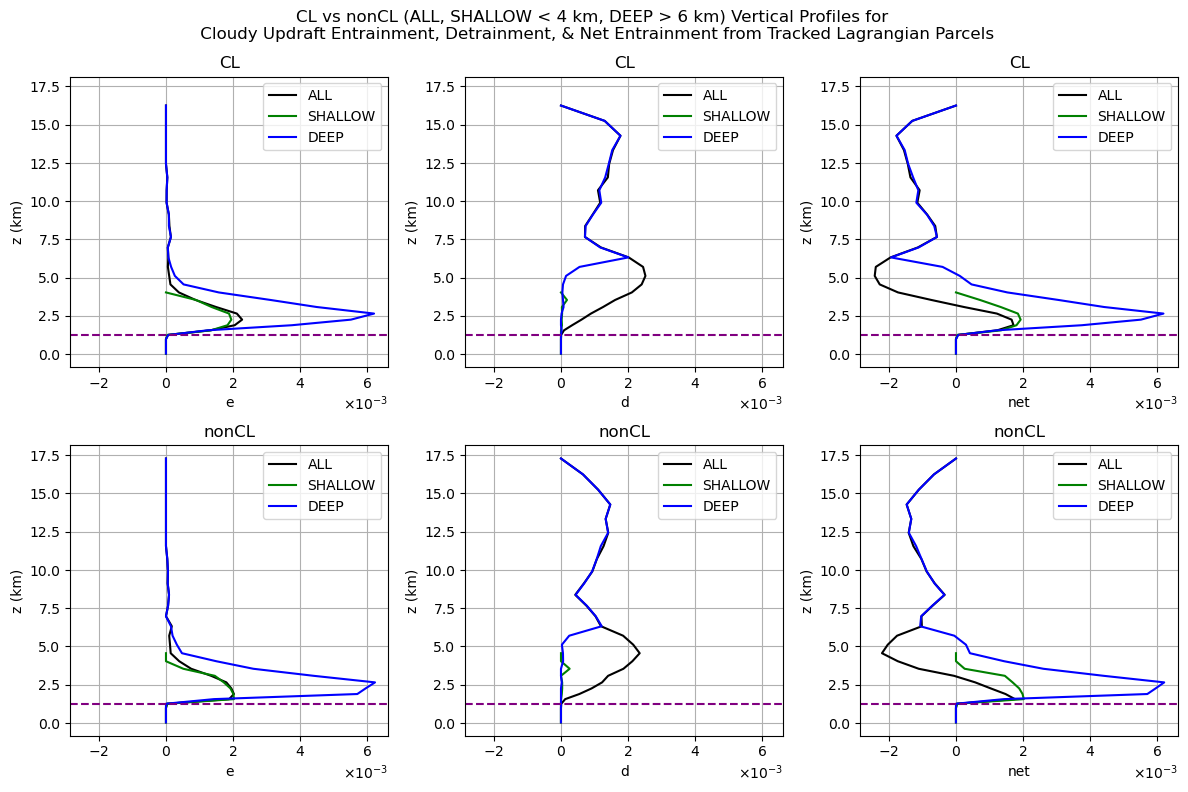

In [17]:
xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_ALL_e, CL_SHALLOW_e, CL_DEEP_e, 'e', 'CL'),
    (CL_ALL_d, CL_SHALLOW_d, CL_DEEP_d, 'd', 'CL'),
    (CL_ALL_net, CL_SHALLOW_net, CL_DEEP_net, 'net', 'CL'),
    (nonCL_ALL_e, nonCL_SHALLOW_e, nonCL_DEEP_e, 'e', 'nonCL'),
    (nonCL_ALL_d, nonCL_SHALLOW_d, nonCL_DEEP_d, 'd', 'nonCL'),
    (nonCL_ALL_net, nonCL_SHALLOW_net, nonCL_DEEP_net, 'net', 'nonCL')
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2,3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])
    
    # Compute the averaged profile
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    # #TESTING
    # ##############################
    # Nx=512;Ny=200;Nt=133;
    # ALL_profile[:,0]/=(Nx*Ny*Nt)
    # SHALLOW_profile[:,0]/=(Nx*Ny*Nt)
    # DEEP_profile[:,0]/=(Nx*Ny*Nt)
    # ##############################
    # #TESTING
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)
    

    #LEGEND
    ax.legend()
    # legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
    # legend_ax.axis("off")  # Hide axes for the legend box
    # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

axs = fig.get_axes()
ax1,ax2,ax3,ax4,ax5,ax6=axs
fix_x_limits([ax1,ax2,ax3,ax4,ax5,ax6])
fix_y_limits([ax1,ax2,ax3,ax4,ax5,ax6])

#ACCESSORIES
plt.suptitle(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft Entrainment, Detrainment, & Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()


#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6= axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4,ax5,ax6])

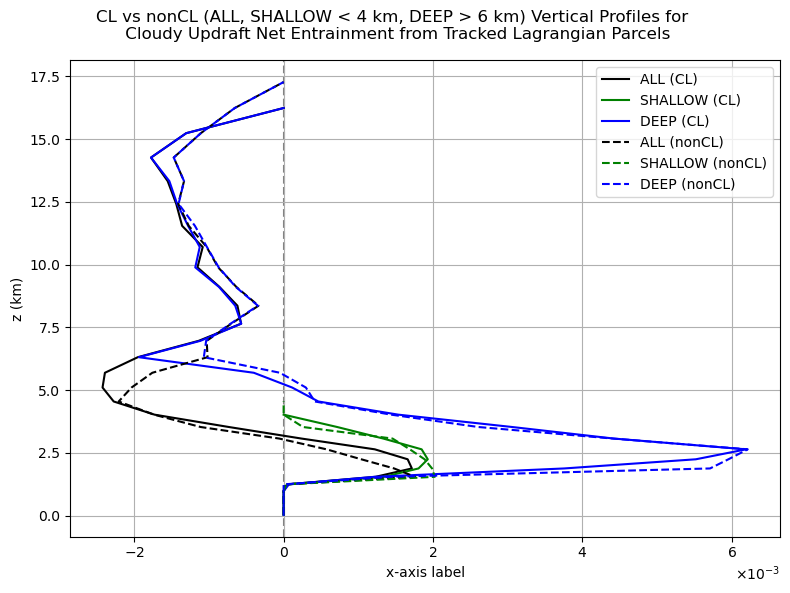

In [18]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (CL_ALL_net, CL_SHALLOW_net, CL_DEEP_net, 'net', 'CL'),
    (nonCL_ALL_net, nonCL_SHALLOW_net, nonCL_DEEP_net, 'net', 'nonCL')
]

cutoff_height=100
# cutoff_height=7.5
# cutoff_height=2
z_cutoff=np.where(CL_ALL_net[:,2]<=cutoff_height)[0][-1] #CUT BELOW CERTAIN Z

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)

    #CUT BELOW CERTAIN Z
    ALL_profile=ALL_profile[:z_cutoff]
    SHALLOW_profile=SHALLOW_profile[:z_cutoff]
    DEEP_profile=DEEP_profile[:z_cutoff]

    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (CL)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (CL)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (CL)')
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonCL)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonCL)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonCL)')

    apply_scientific_notation([ax])

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

ax.axvline(0,linestyle='dashed',color='grey',zorder=-10)

# Show legend
ax.legend()

# Set up the main title and adjust layout
plt.suptitle(f'CL vs nonCL (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()



In [ ]:
##########################################################################################
#SBZ vs nonSBZ Tracked Entrainment Profiles

In [19]:
#FINDING SBZ CONVERGENCE
parcel_z=parcel['z'].data

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# TF=False
# if TF==False:
#     print('Loading In Data')
#     u_data=data['u'].interp(xf=data['xh']).data
#     v_data=data['v'].interp(yf=data['yh']).data
#     TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    # print('calculating convergence and taking mean')
    # Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}' + '.h5'
    with h5py.File(file_path, 'r') as f:
        Conv = f['conv'][:]
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs
def find_SBZ_xmaxs():
    # Define the directory and file path
    dir2 = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
    file_path = dir2 + 'Variable_Calculation/' + 'Convergence' + f'_{res}_{Np_str}' + '.h5'
    
    # Open the HDF5 file in read mode
    with h5py.File(file_path, 'r') as f:
        # Access the 'conv' dataset
        conv_dataset = f['conv']
        
        # Define the vertical level you are interested in
        zlev = 4
        
        # Initialize a list to store the xmaxs for each time step
        xmaxs_list = []

        # Loop over each time step (axis=0 corresponds to time)
        for t in range(conv_dataset.shape[0]):  # conv_dataset.shape[0] is the time dimension size
            # Read the relevant slice for this time step and vertical level
            Conv_t_zlev = conv_dataset[t, zlev, :, :]  # Shape should be (y_size, x_size)
            
            # Calculate the mean across the y-axis
            Conv_ymean = np.mean(Conv_t_zlev, axis=0)  # Mean across the y-axis
            
            # Find the index of the maximum value along the x-axis
            xmax = np.argmax(Conv_ymean)
            
            # Append the result for this time step
            xmaxs_list.append(xmax)
    
    # Convert the list of xmaxs to a numpy array (optional)
    xmaxs = np.array(xmaxs_list)

    return xmaxs #returns SBZ x location for each timestep


def subset_SBZ(out_arr):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_arr.shape[0]):
        
        row=out_arr[ind]
        p=row[0]
        t=row[1]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_arr=out_arr[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

    valid_range=np.arange(out_arr.shape[0])
    nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
    return SBZ_out_arr,nonSBZ_out_arr


# #LOADING CL MAXS FROM CL TRACKING ALGORITHM
# folder = '/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/Project_Algorithms/Tracking_Algorithms/'
# whereSBZ=xr.open_dataset(folder+f'whereCL_{res}_ONLY_SBZS.nc').load()
# whereSBZ=whereSBZ.isel(time=slice(0,len(data['time'])))
# whereSBZ=whereSBZ['maxconv_x']
# def Get_SBZ_X(t,z,y):
#     Conv_X_Max=whereSBZ[t,z,y,:].values
#     return Conv_X_Max
# def subset_SBZ(out_arr):

#     SBZ_subset=[]
#     # test=[] #TESTING
    
#     for ind in np.arange(out_arr.shape[0]):
        
#         row=out_arr[ind]
#         p=row[0]
#         t=row[1]

#         kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
#         value=X[t,p]
#         if np.any((value >= xmaxs - 2*kms) & (value <= xmaxs + 2*kms))==True:
#             SBZ_subset.append(ind)
#             # test.append(p) #TESTING
    
#     SBZ_out_arr=out_arr[SBZ_subset]
#     print(f'there are a total of {len(SBZ_out_arr)} ALL SBZ CL parcels')

#     valid_range=np.arange(out_arr.shape[0])
#     nonSBZ_out_arr=out_arr[list(set(valid_range) - set(SBZ_subset))]
#     print(f'there are a total of {len(nonSBZ_out_arr)} ALL nonSBZ CL parcels')
#     return SBZ_out_arr,nonSBZ_out_arr

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    elif type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 

        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
        
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_arr=ALL_SBZ_out_arr.copy()
    elif type=='nonSBZ':
        out_arr=ALL_nonSBZ_out_arr.copy()

    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_arr)): 
        # if np.mod(ind,5000)==0: print(f'{ind}/{len(out_arr)}')
        #CHECK TO SSEE IF NEXT MOST LOCAL TIME MAX GOES ABOVE ZTHRESHS 
        
        #Get Ascending Range Past LFC For Maximum 120 Minutes Simulation Time
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_arr[ind,2],out_arr[ind,2]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel_z[aboverange,out_arr[ind,0]]/1000
    
        #Takes The time derivative 
        ddx=ddt(above)

        #Checks whether the Local Time Max Is Located Above zthresh
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)

    #SUBSET OUT FOR FINAL RESULT
    out_arr=out_arr[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_arr)} leftover parcels')
    return out_arr#, extendrange
    # print(out_arr)
##############################################################
[ALL_SBZ_out_arr,ALL_nonSBZ_out_arr]=subset_SBZ(ALL_out_arr)
SHALLOW_SBZ_out_arr=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_arr)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_arr=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_arr)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_arr=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_arr)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_arr=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_arr)} DEEP nonSBZ CL parcels')

there are a total of 827 ALL SBZ CL parcels
there are a total of 14067 ALL nonSBZ CL parcels
there are a total of 432 SHALLOW SBZ CL parcels
there are a total of 10059 SHALLOW nonSBZ CL parcels
there are a total of 189 DEEP SBZ CL parcels
there are a total of 1324 DEEP nonSBZ CL parcels


In [28]:
#SBZ After Arrays
ALL_SBZ_out_after_array=find_after_time(ALL_SBZ_out_arr)
SHALLOW_SBZ_out_after_array=np.zeros(len(SHALLOW_SBZ_out_arr),dtype=int)
DEEP_SBZ_out_after_array=find_after_time(DEEP_SBZ_out_arr)

ALL_nonSBZ_out_after_array=find_after_time(ALL_nonSBZ_out_arr)
SHALLOW_nonSBZ_out_after_array=np.zeros(len(SHALLOW_nonSBZ_out_arr),dtype=int)
DEEP_nonSBZ_out_after_array=find_after_time(DEEP_nonSBZ_out_arr)

In [29]:
#FINDING MEAN CLOUD BASE #*****************************
zh=data['zh'].values
w_thresh2=0.5
qcqi_thresh=1e-6
type='all'

if type=='all':
    out_arr=ALL_out_arr.copy()
elif type=='deep':
    out_arr=DEEP_out_arr.copy()
elif type=='shallow':
    out_arr=SHALLOW_out_arr.copy()

zhs=data['zh'].values
profile_array =np.zeros((len(zhs), 2)) #column 1: var, column 2: counter, column 3: list of zhs
profile_array[:,1]=zhs;

# cloudbase_lst=[]
after=4 #20 minutes
for row in range(out_arr.shape[0]):
    if np.mod(row,3000)==0: print(f'{row}/{out_arr.shape[0]}')
    p=out_arr[row,0]
    
    # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
    ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
    ts = np.arange(out_arr[row, 1], ts_end)
    
    zs=Z[ts,p]
    ys=Y[ts,p]
    xs=X[ts,p]

    ws=W[ts,p]
    qcqis=QCQI[ts,p]
    where=np.where((ws>=w_thresh2) & (qcqis>=qcqi_thresh))
    profile_array[zs[where],0]+=1
del after
# print(np.mean(cloudbase_lst))
# print(np.min(cloudbase_lst))
# plt.hist(cloudbase_lst,bins=40,orientation='horizontal');
all_cloudbase=zh[np.where(profile_array[:,0]!=0)[0][0]]
print(all_cloudbase)

0/14894
3000/14894
6000/14894
9000/14894
12000/14894
1.2463868


In [30]:
#MAKING ENTRAINMENT PROFILE ARRAY FUNCTION

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
    
def SBZTrackedEDProfile(type,type2):

    if type2=='general':
        profile_array_e=profile_array_e_g #PRECALCULATED
        profile_array_d=profile_array_d_g #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d
    elif type2=='cloudy':
        profile_array_e=profile_array_e_c #PRECALCULATED
        profile_array_d=profile_array_d_c #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d

    if type=='all':
        out_arr=ALL_SBZ_out_arr
        after_array=ALL_SBZ_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_SBZ_out_arr
        after_array=SHALLOW_SBZ_out_after_array
    elif type=='deep':
        out_arr=DEEP_SBZ_out_arr
        after_array=DEEP_SBZ_out_after_array
    
    
    zhs=data['zh'].values
    e_profile=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    d_profile=e_profile.copy()
    net_profile=e_profile.copy()
    e_profile[:,2]=zhs;d_profile[:,2]=zhs;net_profile[:,2]=zhs
    
    for count, row in enumerate(range(out_arr.shape[0])):
    # for count,row in enumerate(np.arange(100)): #TESTING
        if np.mod(count,1000)==True: print(f'{count*100/len(out_arr):.2f}%')
        after=after_array[row]
        p=out_arr[row,0]
        
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):

            e=profile_array_e[t,z,y,x] 
            d=profile_array_d[t,z,y,x] 
                
            e_profile[z,0]+=e;e_profile[z,1]+=1
            d_profile[z,0]+=d;d_profile[z,1]+=1
            net_profile[z,0]+=e-d;net_profile[z,1]+=1
    
    print('done\n')
    return e_profile,d_profile,net_profile

In [38]:
# type2='general'
type2='cloudy'
[SBZ_ALL_e,SBZ_ALL_d,SBZ_ALL_net] = SBZTrackedEDProfile(type='all',type2=type2)
[SBZ_SHALLOW_e,SBZ_SHALLOW_d,SBZ_SHALLOW_net] = SBZTrackedEDProfile(type='shallow',type2=type2)
[SBZ_DEEP_e,SBZ_DEEP_d,SBZ_DEEP_net] = SBZTrackedEDProfile(type='deep',type2=type2)

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'SBZ_tracked_profiles.h5'

# Write datasets to the HDF5 file
with h5py.File(filePath, 'w') as h5f:
    h5f.create_dataset('SBZ_ALL_e', data=SBZ_ALL_e)
    h5f.create_dataset('SBZ_ALL_d', data=SBZ_ALL_d)
    h5f.create_dataset('SBZ_ALL_net', data=SBZ_ALL_net)
    h5f.create_dataset('SBZ_SHALLOW_e', data=SBZ_SHALLOW_e)
    h5f.create_dataset('SBZ_SHALLOW_d', data=SBZ_SHALLOW_d)
    h5f.create_dataset('SBZ_SHALLOW_net', data=SBZ_SHALLOW_net)
    h5f.create_dataset('SBZ_DEEP_e', data=SBZ_DEEP_e)
    h5f.create_dataset('SBZ_DEEP_d', data=SBZ_DEEP_d)
    h5f.create_dataset('SBZ_DEEP_net', data=SBZ_DEEP_net)


0.12%
done

0.23%
done

0.53%
done



In [39]:
#MAKING ENTRAINMENT PROFILE ARRAY FUNCTION

def averaged_profiles(profile): 
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var
    
def nonSBZTrackedEDProfile(type,type2):

    if type2=='general':
        profile_array_e=profile_array_e_g #PRECALCULATED
        profile_array_d=profile_array_d_g #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d
    elif type2=='cloudy':
        profile_array_e=profile_array_e_c #PRECALCULATED
        profile_array_d=profile_array_d_c #PRECALCULATED
        profile_array_net=profile_array_e-profile_array_d

    if type=='all':
        out_arr=ALL_nonSBZ_out_arr
        after_array=ALL_nonSBZ_out_after_array
    elif type=='shallow':
        out_arr=SHALLOW_nonSBZ_out_arr
        after_array=SHALLOW_nonSBZ_out_after_array
    elif type=='deep':
        out_arr=DEEP_nonSBZ_out_arr
        after_array=DEEP_nonSBZ_out_after_array
    
    
    zhs=data['zh'].values
    e_profile=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    d_profile=e_profile.copy()
    net_profile=e_profile.copy()
    e_profile[:,2]=zhs;d_profile[:,2]=zhs;net_profile[:,2]=zhs
    
    for count, row in enumerate(range(out_arr.shape[0])):
    # for count,row in enumerate(np.arange(100)): #TESTING
        if np.mod(count,1000)==True: print(f'{count*100/len(out_arr):.2f}%')
        after=after_array[row]
        p=out_arr[row,0]
        
        
        # ts=np.arange(out_arr[row,4],out_arr[row,5]+1 + after)
        ts_end = min(out_arr[row, 2] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_arr[row, 1], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):

            e=profile_array_e[t,z,y,x] 
            d=profile_array_d[t,z,y,x] 
                
            e_profile[z,0]+=e;e_profile[z,1]+=1
            d_profile[z,0]+=d;d_profile[z,1]+=1
            net_profile[z,0]+=e-d;net_profile[z,1]+=1
    
    print('done\n')
    return e_profile,d_profile,net_profile

In [40]:
# type2='general'
type2='cloudy'
[nonSBZ_ALL_e,nonSBZ_ALL_d,nonSBZ_ALL_net] = nonSBZTrackedEDProfile(type='all',type2=type2)
[nonSBZ_SHALLOW_e,nonSBZ_SHALLOW_d,nonSBZ_SHALLOW_net] = nonSBZTrackedEDProfile(type='shallow',type2=type2)
[nonSBZ_DEEP_e,nonSBZ_DEEP_d,nonSBZ_DEEP_net] = nonSBZTrackedEDProfile(type='deep',type2=type2)


# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'nonSBZ_tracked_profiles.h5'

# Write datasets to the HDF5 file
with h5py.File(filePath, 'w') as h5f:
    h5f.create_dataset('nonSBZ_ALL_e', data=nonSBZ_ALL_e)
    h5f.create_dataset('nonSBZ_ALL_d', data=nonSBZ_ALL_d)
    h5f.create_dataset('nonSBZ_ALL_net', data=nonSBZ_ALL_net)
    h5f.create_dataset('nonSBZ_SHALLOW_e', data=nonSBZ_SHALLOW_e)
    h5f.create_dataset('nonSBZ_SHALLOW_d', data=nonSBZ_SHALLOW_d)
    h5f.create_dataset('nonSBZ_SHALLOW_net', data=nonSBZ_SHALLOW_net)
    h5f.create_dataset('nonSBZ_DEEP_e', data=nonSBZ_DEEP_e)
    h5f.create_dataset('nonSBZ_DEEP_d', data=nonSBZ_DEEP_d)
    h5f.create_dataset('nonSBZ_DEEP_net', data=nonSBZ_DEEP_net)


0.01%
7.12%
14.22%
21.33%
28.44%
35.55%
42.66%
49.77%
56.88%
63.99%
71.10%
78.20%
85.31%
92.42%
99.53%
done

0.01%
9.95%
19.89%
29.83%
39.78%
49.72%
59.66%
69.60%
79.54%
89.48%
99.42%
done

0.08%
75.60%
done



In [ ]:
##########################################################
#PLOTTING

In [24]:
#READING DATA BACK IN
# type2='general'
type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'SBZ_tracked_profiles.h5'

# Read datasets from the HDF5 file
with h5py.File(filePath, 'r') as h5f:
    SBZ_ALL_e = h5f['SBZ_ALL_e'][:]
    SBZ_ALL_d = h5f['SBZ_ALL_d'][:]
    SBZ_ALL_net = h5f['SBZ_ALL_net'][:]
    SBZ_SHALLOW_e = h5f['SBZ_SHALLOW_e'][:]
    SBZ_SHALLOW_d = h5f['SBZ_SHALLOW_d'][:]
    SBZ_SHALLOW_net = h5f['SBZ_SHALLOW_net'][:]
    SBZ_DEEP_e = h5f['SBZ_DEEP_e'][:]
    SBZ_DEEP_d = h5f['SBZ_DEEP_d'][:]
    SBZ_DEEP_net = h5f['SBZ_DEEP_net'][:]

In [25]:
#READING DATA BACK IN
# type2='general'
type2='cloudy'

# Define the file path
filePath=dir+f'Project_Algorithms/Entrainment/trackout/{type2}_'+'nonSBZ_tracked_profiles.h5'

# Read datasets from the HDF5 file
with h5py.File(filePath, 'r') as h5f:
    nonSBZ_ALL_e = h5f['nonSBZ_ALL_e'][:]
    nonSBZ_ALL_d = h5f['nonSBZ_ALL_d'][:]
    nonSBZ_ALL_net = h5f['nonSBZ_ALL_net'][:]
    nonSBZ_SHALLOW_e = h5f['nonSBZ_SHALLOW_e'][:]
    nonSBZ_SHALLOW_d = h5f['nonSBZ_SHALLOW_d'][:]
    nonSBZ_SHALLOW_net = h5f['nonSBZ_SHALLOW_net'][:]
    nonSBZ_DEEP_e = h5f['nonSBZ_DEEP_e'][:]
    nonSBZ_DEEP_d = h5f['nonSBZ_DEEP_d'][:]
    nonSBZ_DEEP_net = h5f['nonSBZ_DEEP_net'][:]

(-2.076876579073711e-09, 4.875406825053306e-09)
(-0.7796000954695046, 17.05360203469172)


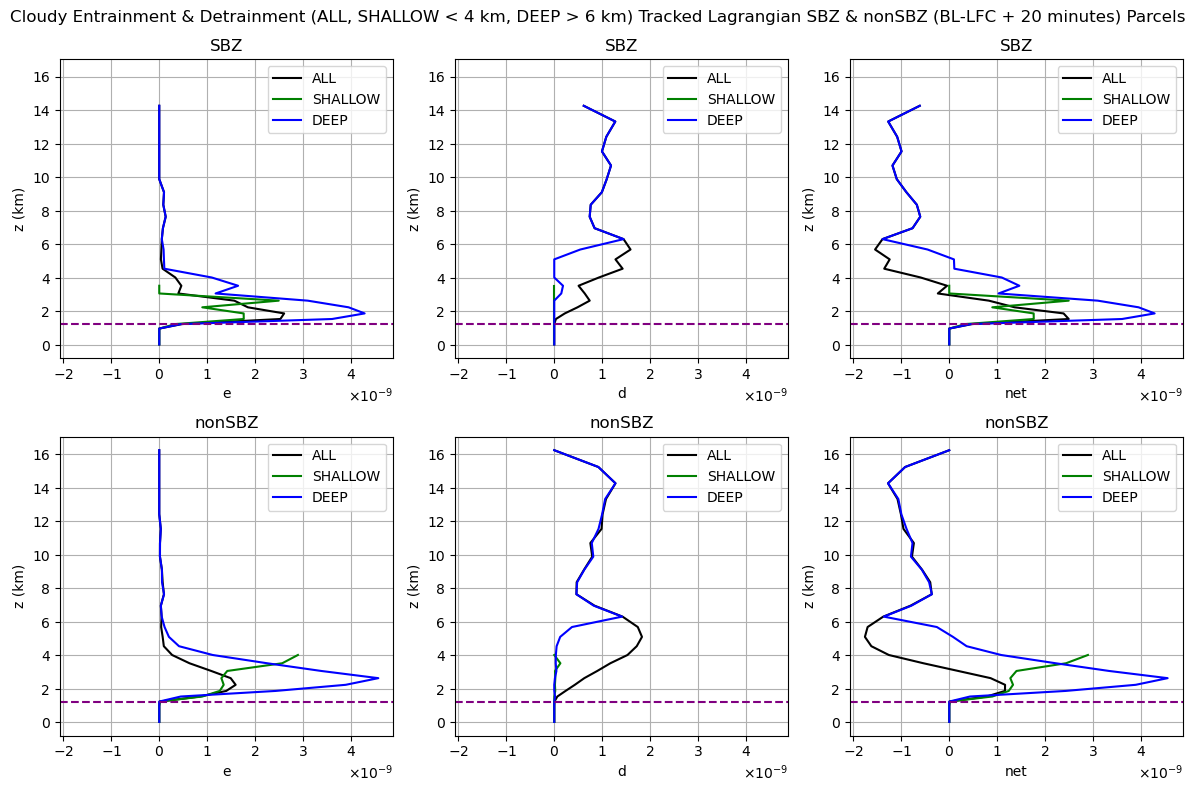

In [26]:
xlims=[] #FIXING XAXIS
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_ALL_e, SBZ_SHALLOW_e, SBZ_DEEP_e, 'e', 'SBZ'),
    (SBZ_ALL_d, SBZ_SHALLOW_d, SBZ_DEEP_d, 'd', 'SBZ'),
    (SBZ_ALL_net, SBZ_SHALLOW_net, SBZ_DEEP_net, 'net', 'SBZ'),
    (nonSBZ_ALL_e, nonSBZ_SHALLOW_e, nonSBZ_DEEP_e, 'e', 'nonSBZ'),
    (nonSBZ_ALL_d, nonSBZ_SHALLOW_d, nonSBZ_DEEP_d, 'd', 'nonSBZ'),
    (nonSBZ_ALL_net, nonSBZ_SHALLOW_net, nonSBZ_DEEP_net, 'net', 'nonSBZ')
]


# Set up the 2x3 gridspec
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2,3, figure=fig)

# Loop through the profiles and plot them on subplots
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    ax = fig.add_subplot(gs[i])
    
    # # Compute the averaged profile
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)
    # ALL_profile=ALL_profile_array.copy()[:,[0,2]]
    # SHALLOW_profile=SHALLOW_profile_array.copy()[:,[0,2]]
    # DEEP_profile=DEEP_profile_array.copy()[:,[0,2]]
    
    
    # Plot the profile
    ax.plot(ALL_profile[:, 0], ALL_profile[:, -1],color='black',label='ALL')
    ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1],color='green',label='SHALLOW')
    ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1],color='blue',label='DEEP')
    ax.set_xlabel(xlabel)
    ax.set_title(CLlabel)
    ax.set_ylabel('z (km)')
    ax.grid(True)
    

    #LEGEND
    ax.legend()
    # legend_ax = fig.add_subplot(gs[0, 2])  # Use the (2, 3) grid slot for the legend
    # legend_ax.axis("off")  # Hide axes for the legend box
    # legend_ax.legend(*ax.get_legend_handles_labels(), loc='center', frameon=False)

axs = fig.get_axes()
ax1,ax2,ax3,ax4,ax5,ax6=axs
fix_x_limits([ax1,ax2,ax3,ax4,ax5,ax6])
fix_y_limits([ax1,ax2,ax3,ax4,ax5,ax6])

#ACCESSORIES
plt.suptitle(f'{type2.title()} Entrainment & Detrainment (ALL, SHALLOW < 4 km, DEEP > 6 km) Tracked Lagrangian SBZ & nonSBZ (BL-LFC + 20 minutes) Parcels')
plt.tight_layout()


# #Mean LFC
# axs = fig.get_axes()
# ax1, ax2, ax3, ax4 = axs
# for axis in [ax1,ax2]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr),mean_LFC(SHALLOW_out_arr),
#                           mean_LFC(DEEP_out_arr))),color='blue',linestyle='dashed',linewidth=1.2)
# for axis in [ax3,ax4]:
#     axis.axhline(np.mean((mean_LFC(ALL_out_arr),mean_LFC(SHALLOW_out_arr),
#                           mean_LFC(DEEP_out_arr))),color='blue',linestyle='dashed',linewidth=1.2)

#MEAN CLOUD BASE
axs = fig.get_axes()
ax1, ax2, ax3, ax4, ax5, ax6= axs
for axis in [ax1,ax2,ax3,ax4,ax5,ax6]:
    axis.axhline(all_cloudbase,color='purple',linestyle='dashed')

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1,ax2,ax3,ax4,ax5,ax6])

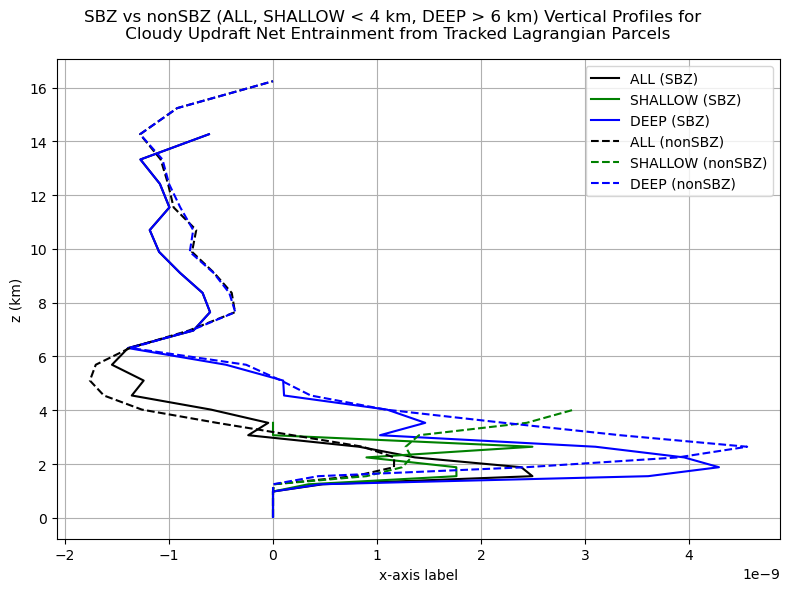

In [23]:
#REDUCING FOR CONFERENCE FIGURE
import matplotlib.pyplot as plt

# List of profile arrays and their corresponding labels and x-axis titles
profiles = [
    (SBZ_ALL_net, SBZ_SHALLOW_net, SBZ_DEEP_net, 'net', 'CL'),
    (nonSBZ_ALL_net, nonSBZ_SHALLOW_net, nonSBZ_DEEP_net, 'net', 'nonCL')
]

# Set up the figure
fig = plt.figure(figsize=(8, 6))

# Create a single axis for all profiles
ax = fig.add_subplot(111)

# Loop through profiles for CL and nonCL
for i, (ALL_profile_array, SHALLOW_profile_array, DEEP_profile_array, xlabel, CLlabel) in enumerate(profiles):
    # Compute the averaged profile for ALL
    ALL_profile = averaged_profiles(ALL_profile_array)
    SHALLOW_profile = averaged_profiles(SHALLOW_profile_array)
    DEEP_profile = averaged_profiles(DEEP_profile_array)
    
    # Plot the profile for ALL (CL and nonCL) on top of each other
    if CLlabel == 'CL':
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], color='black', label='ALL (SBZ)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], color='green', label='SHALLOW (SBZ)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], color='blue', label='DEEP (SBZ)')
    else:
        ax.plot(ALL_profile[:, 0], ALL_profile[:, -1], linestyle='dashed', color='black', label='ALL (nonSBZ)')
        ax.plot(SHALLOW_profile[:, 0], SHALLOW_profile[:, -1], linestyle='dashed', color='green', label='SHALLOW (nonSBZ)')
        ax.plot(DEEP_profile[:, 0], DEEP_profile[:, -1], linestyle='dashed', color='blue', label='DEEP (nonSBZ)')

# Add labels and title
ax.set_xlabel('x-axis label')  # Replace with actual x-axis label
ax.set_ylabel('z (km)')
ax.grid(True)

# Show legend
ax.legend()

# Set up the main title and adjust layout
plt.suptitle(f'SBZ vs nonSBZ (ALL, SHALLOW < 4 km, DEEP > 6 km) Vertical Profiles for \n {type2.title()} Updraft Net Entrainment from Tracked Lagrangian Parcels')
plt.tight_layout()

# Show plot
plt.show()
